## Loan Approval Prediction - End-to-End Classification Project

A complete binary classification workflow: EDA, cleaning, outlier detection, encoding, scaling, model training (5 algorithms), evaluation, comparison, hyperparameter tuning, and saving the best model for deployment in a Streamlit app.

### 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import(
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
)

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)

RANDOM_STATE = 42

### 2. Load Dataset

In [5]:
df = pd.read_csv("loan_prediction_dataset.csv")
df.head()

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
0,56,81788,334,15022,48,Employed,0
1,69,102879,781,21013,24,Self-Employed,1
2,46,58827,779,39687,60,Self-Employed,0
3,32,127188,364,16886,24,Unemployed,0
4,60,25655,307,26256,36,Unemployed,0


### 3. Explore the Dataset

In [6]:
df.tail()

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
1995,63,87580,761,29716,48,Employed,1
1996,67,27368,695,13601,36,Employed,0
1997,69,105436,636,37018,36,Self-Employed,0
1998,24,116136,441,9061,48,Employed,0
1999,20,66403,616,9609,12,Unemployed,0


In [7]:
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))

Shape: (2000, 7)

Columns: ['Age', 'Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term', 'Employment_Status', 'Loan_Approved']


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                2000 non-null   int64 
 1   Income             2000 non-null   int64 
 2   Credit_Score       2000 non-null   int64 
 3   Loan_Amount        2000 non-null   int64 
 4   Loan_Term          2000 non-null   int64 
 5   Employment_Status  2000 non-null   object
 6   Loan_Approved      2000 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 109.5+ KB


In [9]:
df.describe()

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Loan_Approved
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,43.805500,84533.585000,577.055000,25460.315000,35.47800,0.171000
std,14.929203,37771.169751,157.525951,14116.737774,16.98587,0.376603
min,18.000000,20155.000000,300.000000,1060.000000,12.00000,0.000000
25%,31.000000,50925.250000,440.000000,13444.250000,24.00000,0.000000
50%,44.000000,84073.500000,578.500000,25446.000000,36.00000,0.000000
75%,56.000000,117523.250000,715.250000,37949.250000,48.00000,0.000000
max,69.000000,149992.000000,849.000000,49994.000000,60.00000,1.000000


In [11]:
print("Missing Values per column:")
df.isna().sum()

Missing Values per column:


Age                  0
Income               0
Credit_Score         0
Loan_Amount          0
Loan_Term            0
Employment_Status    0
Loan_Approved        0
dtype: int64

In [12]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [13]:
df['Loan_Approved'].value_counts()

Loan_Approved
0    1658
1     342
Name: count, dtype: int64

In [14]:
df['Loan_Approved'].value_counts(normalize=True)*100

Loan_Approved
0    82.9
1    17.1
Name: proportion, dtype: float64

### 4. Handle Missing Values
The dataset has no missing values, so no imputation is required. The code below is kept as a general-purpose safeguard in case the raw data changes.

In [15]:
num_cols = ["Age","Income","Credit_Score","Loan_Amount","Loan_Term"]
cat_cols = ["Employment_Status"]

for c in num_cols:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].median())

for c in cat_cols:
    if df[c].isna().sum() > 0:
        df[c] = df[c].fillna(df[c].mode()[0])

df.isna().sum().sum()

np.int64(0)

### 5. Remove Duplicates

In [18]:
before = df.shape[0]
df.drop_duplicates(inplace=True)
after = df.shape[0]
print(f"Removed {before - after} duplicate rows.")

Removed 0 duplicate rows.


### 6. Exploratory Data Analysis (EDA)

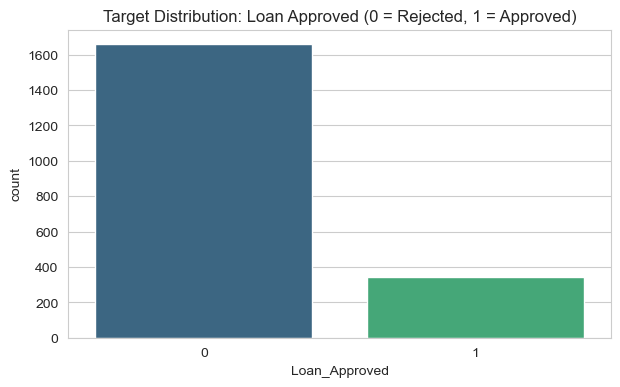

In [19]:
plt.figure()
sns.countplot(x="Loan_Approved", data=df, palette="viridis")
plt.title("Target Distribution: Loan Approved (0 = Rejected, 1 = Approved)")
plt.show()